In [97]:
import matplotlib.pyplot as plt
from itertools import product
import igraph as ig
import numpy as np
from collections import defaultdict
from bitarray.util import int2ba
import pandas as pd
import seaborn as sns

%matplotlib inline

```
     F -- G -- H
    /      \\ /
   D         E
 /  \\      /
A -- B -- C
```

In [140]:
class KagomeLattice:
    def __init__(self, width=1, height=1):
        theta = np.pi / 3
        u = np.array([1, 0])
        v = np.array([np.cos(theta), np.sin(theta)])

        self.lattice_basis = np.c_[u, v]

        named_sites = {
            "A": np.array([0, 0]),
            "B": np.array([1, 0]),
            "C": np.array([2, 0]),
            "D": np.array([0, 1]),
            "E": np.array([2, 1]),
            "F": np.array([0, 2]),
            "G": np.array([1, 2]),
            "H": np.array([2, 2]),
        }

        named_edges = [
            ("AB", 1),
            ("BC", 1),
            ("AD", 1),
            ("BD", 2),
            ("DF", 1),
            ("FG", 1),
            ("GE", 2),
            ("GH", 1),
            ("EH", 1),
            ("CE", 1),
        ]

        edges = [
            ((named_sites[start], named_sites[end]), kind)
            for (start, end), kind in named_edges
        ]

        sites = []
        self.edges = []

        for i, j in product(range(width), range(height)):
            shift = 2 * np.array([i, j])
            for site in named_sites.values():
                sites.append(site + shift)
            for (start, end), kind in edges:
                self.edges.append(
                    (
                        (start + shift, end + shift),
                        kind,
                    )
                )

        self.site_to_num = {}
        new_num = 0
        
        frame = (2 * np.array([width, height]))
        for site in sites:
            canonical_coords = tuple(site % frame)
            if canonical_coords in self.site_to_num:
                self.site_to_num[tuple(site)] = self.site_to_num[canonical_coords]
            else:
                self.site_to_num[canonical_coords] = new_num
                self.site_to_num[tuple(site)] = new_num
                new_num += 1

        self.edges_to_kind = {}
        for (start, end), kind in self.edges:
            self.edges_to_kind[
                (self.site_to_num[tuple(start)], self.site_to_num[tuple(end)])
            ] = kind
            
        sites_df = pd.DataFrame(
            [[num, *coords, (np.array(coords) == np.array(coords) % frame).all()]
             for coords, num in self.site_to_num.items()],
            columns=['num', 'ix', 'iy', 'is_canonical']
        )
        
        sites_df[['emb_x', 'emb_y']] = (self.lattice_basis @ sites_df[['ix', 'iy']].T.values).T
        self.sites_df = sites_df
        
    @property
    def sites(self):
        return sorted(set(self.site_to_num.values()))
    
    @property
    def kind_to_edges(self):
        k_to_e = defaultdict(list)
        for edge, kind in self.edges_to_kind.items():
            k_to_e[kind].append(edge)
        return k_to_e
            
    def as_igraph(self):
        edges, kinds = zip(*self.edges_to_kind.items())
        return ig.Graph(edges=edges, edge_attrs={'kind': kinds})
    
    def get_automorphisms(self):
        g = self.as_igraph()
        return g.get_automorphisms_vf2(edge_color=g.es['kind'])
                        
    def plot(self, spins=None):
        if spins is not None:
            spins_df = pd.DataFrame(dict(spin=spins))
            sites_df = self.sites_df.merge(spins_df, left_on='num', right_index=True)
        else:
            sites_df = self.sites_df
        
        fg = sns.lmplot(sites_df,  hue='spin' if spins is not None else None,
                    x='emb_x', y='emb_y', fit_reg=False)
        
        
        for (start, end), kind in self.edges:
            fg.ax.plot(
                *zip(self.lattice_basis @ start, self.lattice_basis @ end),
                color=f"C{kind}",
            )
            
        
        
        for site, num in self.site_to_num.items():
            fg.ax.annotate("  " + str(num), self.lattice_basis @ site)

lat.site_to_num.values()=dict_values([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 0, 1, 2, 10, 0, 3, 11, 5, 8, 10, 0])
lat.kind_to_edges=defaultdict(<class 'list'>, {1: [(0, 1), (1, 2), (0, 3), (3, 5), (5, 6), (6, 7), (4, 7), (2, 4), (5, 8), (8, 0), (9, 2), (7, 9), (2, 10), (10, 0), (7, 11), (11, 5)], 2: [(1, 3), (6, 4), (6, 8), (1, 9), (10, 4), (11, 3), (11, 9), (10, 8)]})
    num  ix  iy  is_canonical  emb_x     emb_y
0     0   0   0          True    0.0  0.000000
1     1   1   0          True    1.0  0.000000
2     2   2   0          True    2.0  0.000000
3     3   0   1          True    0.5  0.866025
4     4   2   1          True    2.5  0.866025
5     5   0   2          True    1.0  1.732051
6     6   1   2          True    2.0  1.732051
7     7   2   2          True    3.0  1.732051
8     8   0   3          True    1.5  2.598076
9     9   2   3          True    3.5  2.598076
10    0   0   4         False    2.0  3.464102
11    1   1   4         False    3.0  3.464102
12    2   2   4         Fa

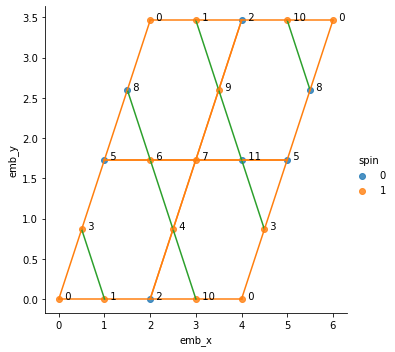

In [141]:
lat = KagomeLattice(width=2, height=2)
lat.plot(spins=np.random.randint(2, size=len(lat.sites)))
# assert sorted(set(lat.site_to_num.values())) == list(range(24))
print(f"{lat.site_to_num.values()=}")
print(f"{lat.kind_to_edges=}")
print(lat.sites_df)

In [142]:
import numpy as np
import scipy.sparse.linalg

import lattice_symmetries as ls


class HeisenbergJ1J2:
    def __init__(self, lat, J1=1., J2=1., use_symmetries=True):
        self.lat = lat
        
        number_spins = len(lat.sites)  # System size
        
        print(f"{number_spins=}")
        hamming_weight = number_spins // 2  # Hamming weight (i.e. number of spin ups)

        # Constructing symmetries

        if use_symmetries:
            symmetries = [ls.Symmetry(automorphism, sector=0) for automorphism in lat.get_automorphisms()]
        else:
            symmetries = []
            
        # Constructing the group
        self.symmetry_group = ls.Group(symmetries)
        print("Symmetry group contains {} elements".format(len(self.symmetry_group)))

        # Constructing the basis
        self.basis = ls.SpinBasis(
            self.symmetry_group,
            number_spins=number_spins,
            hamming_weight=hamming_weight,
            spin_inversion=1,
        )
        self.basis.build()  # Build the list of representatives, we need it since we're doing ED
        print("Hilbert space dimension is {}".format(self.basis.number_states))
        
        
        # Heisenberg Hamiltonian
        # fmt: off
        σ_x = np.array([ [0, 1]
                       , [1, 0] ])
        σ_y = np.array([ [0 , -1j]
                       , [1j,   0] ])
        σ_z = np.array([ [1,  0]
                       , [0, -1] ])
        # fmt: on
        σ_p = σ_x + 1j * σ_y
        σ_m = σ_x - 1j * σ_y

        matrix = 0.5 * (np.kron(σ_p, σ_m) + np.kron(σ_m, σ_p)) + np.kron(σ_z, σ_z)

        self.hamiltonian = ls.Operator(self.basis, 
                                       [ls.Interaction(J1 * matrix, lat.kind_to_edges[1]),
                                        ls.Interaction(J2 * matrix, lat.kind_to_edges[2])])
    
    @property
    def number_spins(self):
        return len(self.lat.sites)
    
    def unpack_states(self):
        unp_states = []
        for state in self.basis.states:
            unp_state = list(int2ba(int(state)))
            unp_state = [0] * (self.number_spins - len(unp_state)) + unp_state
            unp_states.append(unp_state)
        return np.array(unp_states)
        
    def get_ground_state(self, k=1):
        # Diagonalize the Hamiltonian using ARPACK
        eigenvalues, eigenstates = ls.diagonalize(self.hamiltonian, k=k)
        print("Ground state energy is {:.10f}".format(eigenvalues[0]))
        return eigenvalues, eigenstates
        # assert np.isclose(eigenvalues[0], -18.06178542)

In [161]:
int2ba(34)

bitarray('100010')

In [143]:
system = HeisenbergJ1J2(KagomeLattice(width=2, height=3))

number_spins=18
Symmetry group contains 12 elements
Hilbert space dimension is 2102


In [146]:
energy, state = system.get_ground_state()

Ground state energy is -31.0548143836


In [155]:
max_amp = max(np.abs(state))
max_state_idx = np.abs(state).argmax()

In [157]:
max_state_idx

1949

In [158]:
state[max_state_idx]

array([0.1637656])

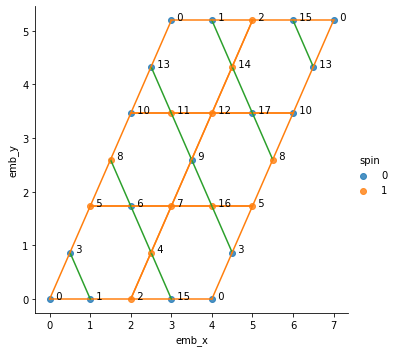

In [160]:
system.lat.plot(spins=system.unpack_states()[max_state_idx])

In [64]:
system.lat.site_to_num

{(0, 0): 0,
 (1, 0): 1,
 (2, 0): 2,
 (0, 1): 3,
 (2, 1): 4,
 (0, 2): 5,
 (1, 2): 6,
 (2, 2): 7,
 (0, 3): 8,
 (2, 3): 9,
 (0, 4): 10,
 (1, 4): 11,
 (2, 4): 12,
 (0, 5): 13,
 (2, 5): 14,
 (0, 6): 0,
 (1, 6): 1,
 (2, 6): 2,
 (3, 0): 15,
 (4, 0): 0,
 (4, 1): 3,
 (3, 2): 16,
 (4, 2): 5,
 (4, 3): 8,
 (3, 4): 17,
 (4, 4): 10,
 (4, 5): 13,
 (3, 6): 15,
 (4, 6): 0}

In [34]:
vals, vecs = scipy.sparse.linalg.eigs(system.hamiltonian.to_csr(), k=1, which='SR')

In [44]:
np.array(list(int2ba(34)))

array([1, 0, 0, 0, 1, 0])

In [37]:
system.basis.states

array([  511,   767,   895, ..., 58938, 59224, 60216], dtype=uint64)